$\large \text{Introduction}$

To begin any data analysis task in python, the obligatory cell importing all libraries and methods is required:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

from matplotlib.ticker import FormatStrFormatter #Used to allow altering the sig fig count on axis values
from IPython.display import Markdown #Used to allow for use of python variables in LaTeX code

The following command is used to disable unwanted warning (not error!) messages

In [2]:
pd.options.mode.chained_assignment = None

In this task, the goal is to make a measurement of the Hubble constant, $H_0$, using measured data on Cepheid variable stars, Type la supernovae and their host galaxies, where:

$
\begin{array}{l}
\bullet\ \text{Cepheid variable stars: Post-main sequence stars that have varying brightness with a constant period} \\
\bullet\ \text{Type la supernovae: A supernova that is characterised by the lack of hydrogen in its spectrum}
\end{array} 
$

This will be done using this four step process:

$
\begin{array}{l}
\text{Part A}:\ \text{Find Cepheid } M_{\text{abs}} \text{ using stars at known distance} \\
\text{Part B}:\ \text{Calibrate SNIa } M_{\text{abs}} \text{ using galaxies with both Cepheids and SNIa}\\
\text{Part C}:\ \text{Measure galaxy distances using SNIa}\\
\text{Part D}:\ \text{ Use galaxy distances and redshifts to calculate } H_0
\end{array}
$

$
\begin{aligned}
&\large \text{Part A: Find Cepheid } M_{\text{abs}}\text{using stars at known distance} \\
\end{aligned}
$

Firstly, I'll load the data of the 339 Cepheids in the Large Magallanic Cloud (LMC) taken using the Hubble Space Telescope (HST) and the OGLE observatory as a dataframe.

In [ ]:
dfCepheids_lmc = pd.read_csv("./data/lmc_cepheids_phot.csv")
dfCepheids_lmc.head()

For the analysis, only data taken using the HST is required, so I'll create a new dataset that only contains stars observed using it.

In [ ]:
dfCepheids_lmc_hst = dfCepheids_lmc[dfCepheids_lmc["obs_type"] == "HST"]
dfCepheids_lmc_hst.head()

,ID,P,apparent_mag,apparent_mag_unc,obs_type
270,OGL-0434,30.34,10.96488,0.080834,HST
271,OGL-0501,23.28,11.41102,0.080834,HST
272,OGL-0510,36.81,10.78224,0.091315,HST
273,OGL-0512,39.36,10.59382,0.080834,HST
274,OGL-0528,35.73,10.82628,0.083285,HST


Having created the dataframe, dfCepheids_lmc_hst, I'll calculate the absolute magnitude of observed objects using the apparent magnitude, apparent_mag, and distance modulus of the LMC as given in the documentation. This value will be placed in a new column for each row, titled "absolute_mag".

I will use the following formula: 
$$\mu = m_{app} - M_{abs}$$
Rearranged as,
$$M_{abs} = m_{app} - \mu_{LMC}, \text{ where } \mu_{LMC}=18.477\pm0.026$$

In [ ]:
def absolute_mag(apparent_mag,mu):
    return apparent_mag - mu

dfCepheids_lmc_hst["absolute_mag"] = absolute_mag(dfCepheids_lmc_hst["apparent_mag"],18.477)
dfCepheids_lmc_hst.head()

,ID,P,apparent_mag,apparent_mag_unc,obs_type,absolute_mag
270,OGL-0434,30.34,10.96488,0.080834,HST,-7.51212
271,OGL-0501,23.28,11.41102,0.080834,HST,-7.06598
272,OGL-0510,36.81,10.78224,0.091315,HST,-7.69476
273,OGL-0512,39.36,10.59382,0.080834,HST,-7.88318
274,OGL-0528,35.73,10.82628,0.083285,HST,-7.65072


In order to calculate the uncertainty for absolute magnitude, I need uncertainties of both apparent magnitude and distance modulus.

The uncertainties for apparent magnitude are given in the dataframe and the uncertainty of the distance modulus is given in the documentation,

$$ \sigma_{\mu} = 0.026$$

Next, I will calculate the uncertainties of the absolute magnitudes of the stars using error propagation,

$$ \sigma_{z}^2 = \frac{\partial f}{\partial x}^2 \sigma_{x}^2 + \frac{\partial f}{\partial y}^2 \sigma_{y}^2 + ... $$

According to the equation, $$M_{\text{abs}} = m_{\text{app}} - \mu$$

$$ \sigma_{M_{\text{abs}}}^2 = \frac{\partial M_{\text{abs}}}{\partial m_{\text{app}}}^2 \sigma_{m_{\text{app}}}^2 + \frac{\partial M_{\text{abs}}}{\partial \mu}^2 \sigma_{\mu}^2 $$

$ {\frac{\partial M_{\text{abs}}}{\partial m_{\text{app}}}} = 1, {\frac{\partial M_{\text{abs}}}{\partial \mu}} = -1 $
$  ~~~~~~\implies ~~~~~~\sigma_{M_{\text{abs}}} = \sqrt{\sigma_{m_{\text{app}}}^2 + \sigma_{\mu}^2}$

I will then place $ \sigma_{M_{\text{abs}}} $ in a new column, titled "absolute_mag_unc".

In [ ]:
def unc(x,y):
    return np.sqrt(x**2 + y**2)

dfCepheids_lmc_hst["absolute_mag_unc"] = unc(dfCepheids_lmc_hst["apparent_mag_unc"],0.026)

dfCepheids_lmc_hst.head()

,ID,P,apparent_mag,apparent_mag_unc,obs_type,absolute_mag,absolute_mag_unc
270,OGL-0434,30.34,10.96488,0.080834,HST,-7.51212,0.084912
271,OGL-0501,23.28,11.41102,0.080834,HST,-7.06598,0.084912
272,OGL-0510,36.81,10.78224,0.091315,HST,-7.69476,0.094944
273,OGL-0512,39.36,10.59382,0.080834,HST,-7.88318,0.084912
274,OGL-0528,35.73,10.82628,0.083285,HST,-7.65072,0.087249


Next, I will use the curve_fit method on the cepheid period luminosity relation,

$$ M_{abs} = a(log_{10}P - 1.0)+b $$

in order to estimate the relation's gradient, $a$, y-intercept, $b$, and their uncertainties.

In [ ]:
def absolute_mag_P(P,a,b):
    return a*(np.log10(P) - 1.0)+b

popt,pcov = curve_fit(absolute_mag_P,dfCepheids_lmc_hst["P"],dfCepheids_lmc_hst["absolute_mag"])
a = popt[0]
b = popt[1]
a_unc = np.sqrt(pcov[0][0])
b_unc = np.sqrt(pcov[1][1])

Markdown(rf"$$\begin{{align}} & \Large \text{{Gradient: }} a={a:.2f} \pm {a_unc:.2f} \\ & \Large \text{{y-Intercept: }} b={b:.2f} \pm {b_unc:.2f} \\ \end{{align}}$$")

$$\begin{align} & \Large \text{Gradient: } a=-3.35 \pm 0.04 \\ & \Large \text{y-Intercept: } b=-5.81 \pm 0.01 \\ \end{align}$$

Finally, I will produce a plot showing the relationship between period and luminosity of cepheid stars,

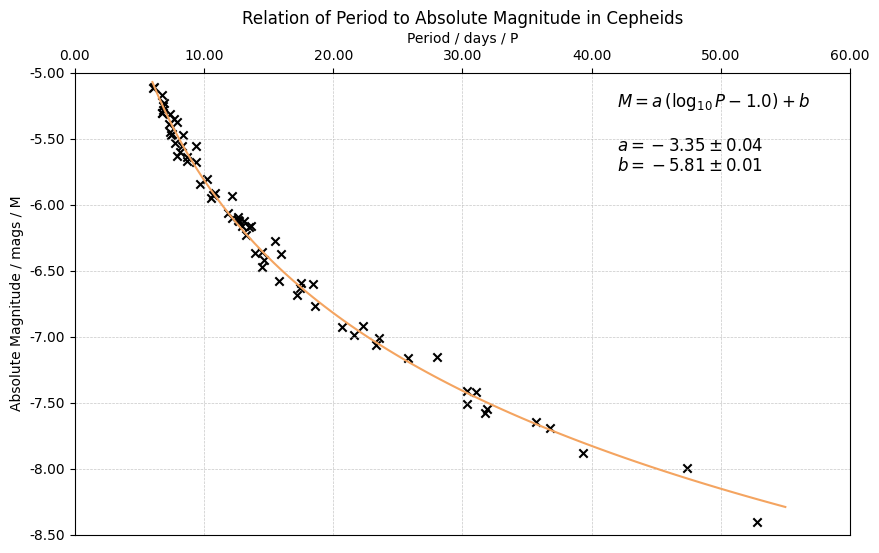

In [ ]:
x = np.linspace(6,55,100)

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.scatter(dfCepheids_lmc_hst["P"],dfCepheids_lmc_hst["absolute_mag"], marker="x", color="black")
ax.plot(x,absolute_mag_P(x,a,b),color="sandybrown",linestyle="solid")
ax.set_xlabel("Period / days / P")
ax.xaxis.set_label_position('top')
ax.set_ylabel("Absolute Magnitude / mags / M")
ax.set_title("Relation of Period to Absolute Magnitude in Cepheids")
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.xaxis.set_ticks_position('top')
ax.yaxis.set_ticks_position('left')
ax.set_xlim(0,60)
ax.set_ylim(-8.50,-5.00)
textstr = (
    rf"$M = a\,(\log_{{10}}P - 1.0) + b$" "\n" "\n"
    rf"$a = {a:.2f} \pm {a_unc:.2f}$" "\n"
    rf"$b = {b:.2f} \pm {b_unc:.2f}$"
)

ax.text(0.70, 0.96, textstr,transform=ax.transAxes,va='top',fontsize=12)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

To test the functions for absolute magnitude and its uncertainty, I will calculate these for a Cepheid with a period of 10 days, $ P=10 $

I will calculate the uncertainties of the absolute magnitudes of the stars using error propagation,

$$ \sigma_{z}^2 = \frac{\partial f}{\partial x}^2 \sigma_{x}^2 + \frac{\partial f}{\partial y}^2 \sigma_{y}^2 + ... $$

According to the equation, $$ M_{\text{abs}} = a( \log_{10}P -1.0) + b $$

$$ \sigma_{M_{\text{abs}}}^2 = \frac{\partial M_{\text{abs}}}{\partial a}^2 \sigma_{a}^2 + \frac{\partial M_{\text{abs}}}{\partial b}^2 \sigma_{b}^2 $$

$ \frac{\partial M_{\text{abs}}}{\partial a} = \log_{10}(P) - 1.0 $, $ \frac{\partial M_{\text{abs}}}{\partial b} = 1 $

For a period of $ P=10$ days, $ \frac{\partial M_{\text{abs}}}{\partial a}=\log_{10}(10) - 1.0 = 0,\frac{\partial M_{\text{abs}}}{\partial b} = 1 ~~~~~~\implies ~~~~~~\sigma_{M_{\text{abs}}} = \sqrt{\sigma_{b}^2} =\sigma_{b} $


In [ ]:
cepheid_10AbsMag = absolute_mag_P(10,a,b)
cepheid_10AbsMagUnc = unc(0,b_unc)

Markdown(rf"$$\Large {{\text{{For }}}}P=10, ~~M_{{\text{{abs}}}} ={cepheid_10AbsMag:.2f} \pm {cepheid_10AbsMagUnc:.2f}$$")

$$\Large {\text{For }}P=10, ~~M_{\text{abs}} =-5.81 \pm 0.01$$

$ 
\begin{aligned}
&\large \text{Part B: Find Supernova la } M_{\text{abs}}\text{using galaxies with Cepheids and supernovae} \\
\end{aligned}
$


Firstly, I will load the data of cepheid host galaxies (cep_host_galaxies.csv) and supernova observations (sn_observations.csv) into their respective dataframes.

In [ ]:
dfCep_host_galaxy = pd.read_csv("./data/cep_host_galaxies.csv")
dfSupernova_obs= pd.read_csv("./data/sn_observations.csv")
dfCep_host_galaxy.head()

,Galaxy,app_mag_10d,app_mag_10d_unc
0,M101,23.2722,0.0005
1,M1337,27.0455,0.0218
2,N0691,26.9081,0.0063
3,N1015,26.7474,0.0051
4,N105A,28.7264,0.0729


In [ ]:
dfSupernova_obs.head()

,Galaxy,SN,sn_app_mag,sn_app_mag_unc
0,M101,2011fe,9.780,0.115
1,M1337,2006D,13.655,0.106
2,N0691,2005W,13.602,0.139
3,N1015,2009ig,13.350,0.094
4,N1309,2002fk,13.209,0.082


To simplify further calculations and analysis, I will merge the two data frames together on the "Galaxy" column, which both dataframes share.

In [ ]:
dfCepGalaxy_Sn = pd.merge(dfCep_host_galaxy,dfSupernova_obs,on="Galaxy")
dfCepGalaxy_Sn.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc
0,M101,23.2722,0.0005,2011fe,9.780,0.115
1,M1337,27.0455,0.0218,2006D,13.655,0.106
2,N0691,26.9081,0.0063,2005W,13.602,0.139
3,N1015,26.7474,0.0051,2009ig,13.350,0.094
4,N1309,26.7299,0.0035,2002fk,13.209,0.082


Next, I will determine the distance modulus of a galaxy using the apparent magnitude of a Cepheid with a period of 10 days given in the dataframe and the absolute magnitude calculated in Part A. 

I will use the equation,

$$\mu = m_{\text{app}} - M_{\text{abs}}$$

I will then use uncertainty propagation, which I've already defined the equation for in this relationship
$$\sigma_{\mu} = \sqrt{\sigma_{m_{\text{app}}}^2 + \sigma_{M_{\text{abs}}}^2}$$


In [ ]:
def dist_mod(m_app,m_abs):
    return m_app - m_abs
dfCepGalaxy_Sn["dist_mod_10d"] = dist_mod(dfCepGalaxy_Sn["app_mag_10d"],cepheid_10AbsMag)
dfCepGalaxy_Sn["dist_mod_10d_unc"] = unc(dfCepGalaxy_Sn["app_mag_10d_unc"],cepheid_10AbsMagUnc) 
dfCepGalaxy_Sn.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc,dist_mod_10d,dist_mod_10d_unc
0,M101,23.2722,0.0005,2011fe,9.780,0.115,29.086864,0.010578
1,M1337,27.0455,0.0218,2006D,13.655,0.106,32.860164,0.024226
2,N0691,26.9081,0.0063,2005W,13.602,0.139,32.722764,0.012302
3,N1015,26.7474,0.0051,2009ig,13.350,0.094,32.562064,0.011733
4,N1309,26.7299,0.0035,2002fk,13.209,0.082,32.544564,0.011131


Next, I will calculate the absolute magnitude and its uncertainty for each supernova using the supernova apparent magnitude and distance modulus determined in the previous step ("absolute_mag()"), using this equation,

$$M_{\text{abs}} = m_{\text{app}} - \mu$$
and uncertainty propagation, which I've already defined the equation for in this relationship ("unc()"),
$$\sigma_{M_{\text{abs}}} = \sqrt{\sigma_{m_{\text{app}}}^2 + \sigma_{\mu}^2}$$

In [ ]:
dfCepGalaxy_Sn["sn_abs_mag"] = absolute_mag(dfCepGalaxy_Sn["sn_app_mag"],dfCepGalaxy_Sn["dist_mod_10d"])
dfCepGalaxy_Sn["sn_abs_mag_unc"] = unc(dfCepGalaxy_Sn["sn_app_mag_unc"],dfCepGalaxy_Sn["dist_mod_10d_unc"])
dfCepGalaxy_Sn.head()

,Galaxy,app_mag_10d,app_mag_10d_unc,SN,sn_app_mag,sn_app_mag_unc,dist_mod_10d,dist_mod_10d_unc,sn_abs_mag,sn_abs_mag_unc
0,M101,23.2722,0.0005,2011fe,9.780,0.115,29.086864,0.010578,-19.306864,0.115485
1,M1337,27.0455,0.0218,2006D,13.655,0.106,32.860164,0.024226,-19.205164,0.108733
2,N0691,26.9081,0.0063,2005W,13.602,0.139,32.722764,0.012302,-19.120764,0.139543
3,N1015,26.7474,0.0051,2009ig,13.350,0.094,32.562064,0.011733,-19.212064,0.094729
4,N1309,26.7299,0.0035,2002fk,13.209,0.082,32.544564,0.011131,-19.335564,0.082752


Lastly, I will calculate average absolute magnitude of the supernovae and its uncertainty and plot a histogram of the absolute magnitudes of the supernovae.

I will calculate the average values using,

$$ \bar{X} = \frac{\sum X}{N} $$

where, 
$$ 
\begin{align}
& \bar{M}_{abs} = \text{average absolute magnitude} \\
& \bar{\sigma}_{M_{abs}} = \text{average uncertainty of absolute magnitude} \\
\end{align}
$$ 

In [ ]:
avg_sn_abs_mag = np.sum(dfCepGalaxy_Sn["sn_abs_mag"]) / len(dfCepGalaxy_Sn)
avg_sn_abs_mag_unc = np.sum(dfCepGalaxy_Sn["sn_abs_mag_unc"]) / len(dfCepGalaxy_Sn)

Markdown(rf"$$\begin{{align}} & \Large \bar{{M}}_{{\text{{abs}}}}={avg_sn_abs_mag:.2f}\\ & \Large \bar{{\sigma}}_{{M_{{\text{{abs}}}}}}={avg_sn_abs_mag_unc:.2f} \\ \end{{align}}$$")

$$\begin{align} & \Large \bar{M}_{\text{abs}}=-19.23\\ & \Large \bar{\sigma}_{M_{\text{abs}}}=0.11 \\ \end{align}$$

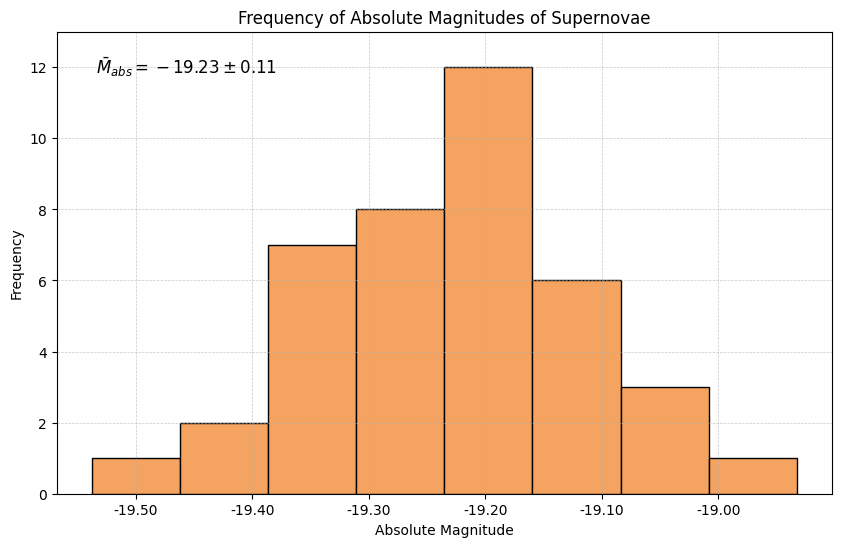

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
ax.hist(dfCepGalaxy_Sn["sn_abs_mag"],bins="auto",edgecolor="black",color="sandybrown")
ax.set_xlabel("Absolute Magnitude")
ax.set_ylabel("Frequency")
ax.set_title("Frequency of Absolute Magnitudes of Supernovae")
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_ylim(0,13)
textstr = (
    f"$\\bar{{M}}_{{abs}} = {avg_sn_abs_mag:.2f} \\pm {avg_sn_abs_mag_unc:.2f} $ \n"
)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, va="top",fontsize=12)
plt.show()



$ 
\begin{aligned}
&\large \text{Part C: Use type la supernovae distances and redshifts to calculate } H_0 \\
\end{aligned}
$

Now that $ \bar{{M}}_{{abs}} $ for type la supernovae has been determined, distances to galaxies can be calculated using other data on supernovae in the "big_sn_sample.csv" file.

In [ ]:
dfSn = pd.read_csv("./data/big_sn_sample.csv")
dfSn.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc
0,2011fe,0.00122,0.00084,9.74571,1.516210
1,2011fe,0.00122,0.00084,9.80286,1.517230
2,2012cg,0.00256,0.00084,11.47030,0.781906
3,2012cg,0.00256,0.00084,11.49190,0.798612
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798


Since values for apparent magnitude and the mean absolute magnitude are known, a distance modulus can be calculated using the equation:

$$\mu = m_{\text{app}} - M_{\text{abs}}$$

I've already defined the function for this calculation as "dist_mod"

I will then use uncertainty propagation, which I've already defined the equation for in this relationship:

$$\sigma_{\mu} = \sqrt{\sigma_{m_{\text{app}}}^2 + \sigma_{M_{\text{abs}}}^2}$$


In [ ]:
dfSn["sn_dist_mod"] = dist_mod(dfSn["sn_app_mag"],avg_sn_abs_mag)
dfSn["sn_dist_mod_unc"] = unc(dfSn["sn_app_mag_unc"],avg_sn_abs_mag_unc)
dfSn.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc,sn_dist_mod,sn_dist_mod_unc
0,2011fe,0.00122,0.00084,9.74571,1.516210,28.978604,1.520502
1,2011fe,0.00122,0.00084,9.80286,1.517230,29.035754,1.521519
2,2012cg,0.00256,0.00084,11.47030,0.781906,30.703194,0.790196
3,2012cg,0.00256,0.00084,11.49190,0.798612,30.724794,0.806731
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798,30.755594,0.888166


To simplify further calculations, the distance of supernovae should be found using the relationship:

$$\mu = 5\log_{10}{d} − 5 $$

Rearranging,

$$ d = 10^{\frac{\mu}{5}+1} $$

Here, d is in parsecs, but it is easier to use megaparsecs, since the Hubble constant is defined in terms of Mpc, where $ 1Mpc = 10^6 $ parsecs, so:

$$ 
\begin{align}
d / Mpc&= 10^{\frac{\mu}{5}+1} \times 10^{-6} \\
& d=10^{\frac{\mu}{5}-5}\\
\end{align}
$$

To propagate uncertainty from $\mu$ to $d$, use uncertainty propagation,

$$ \sigma_{z}^2 = \frac{\partial f}{\partial x}^2 \sigma_{x}^2 + \frac{\partial f}{\partial y}^2 \sigma_{y}^2 + ... $$

According to the equation,

$$ d=10^{\frac{\mu}{5}-5} $$

$$ \sigma_{d}^2 = \frac{\partial d}{\partial \mu}^2 \sigma_{\mu}^2$$
$ \frac{\partial d}{\partial \mu} = 10^{\frac{\mu}{5} - 5} \times \frac{\ln(10)}{5} \implies \sigma_{d} = \sqrt{(10^{\frac{\mu}{5} - 5} \times \frac{\ln(10)}{5})^2 \times \sigma_{\mu}^2} = \frac{\ln(10)10^{\frac{\mu}{5} - 5}}{5}\sigma_{\mu} $

In [ ]:
def dist(dist_mod):
    return 10**((dist_mod)/5 - 5)
def dist_unc(dist_mod, dist_mod_unc):
    return (10**((dist_mod/5)-5))*(np.log(10)/5)*dist_mod_unc

dfSn["sn_dist/Mpc"] = dist(dfSn["sn_dist_mod"])
dfSn["sn_dist_unc/Mpc"] = dist_unc(dfSn["sn_dist_mod"],dfSn["sn_dist_mod_unc"])
dfSn.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc,sn_dist_mod,sn_dist_mod_unc,sn_dist/Mpc,sn_dist_unc/Mpc
0,2011fe,0.00122,0.00084,9.74571,1.516210,28.978604,1.520502,6.247708,4.374751
1,2011fe,0.00122,0.00084,9.80286,1.517230,29.035754,1.521519,6.414322,4.494422
2,2012cg,0.00256,0.00084,11.47030,0.781906,30.703194,0.790196,13.824159,5.030596
3,2012cg,0.00256,0.00084,11.49190,0.798612,30.724794,0.806731,13.962357,5.187200
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798,30.755594,0.888166,14.161809,5.792399


Now, the Hubble constant can be calculated using the redshift data in tandem with the calculated distances. I will plot distance over redshift to visualise the relationship.

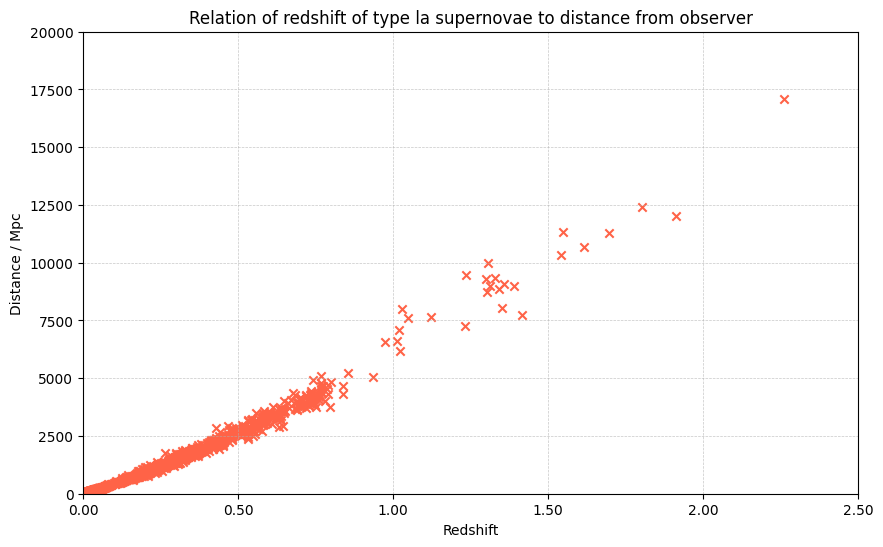

In [ ]:
fig = plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.scatter(dfSn["redshift"],dfSn["sn_dist/Mpc"],color="tomato",marker="x")
ax.set_xlabel("Redshift")
ax.set_ylabel("Distance / Mpc")
ax.set_title("Relation of redshift of type la supernovae to distance from observer")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlim(0,2.50)
ax.set_ylim(0,20000)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

The data points are clustered together in the lower magniutudes of distance, which can be amended using a logarithmic scale to reduce the distances between data points.

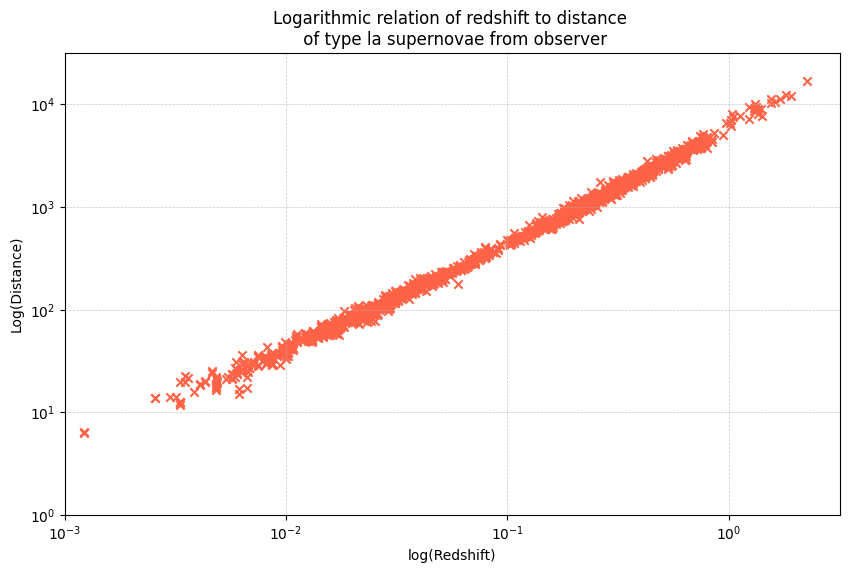

In [ ]:
fig = plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.scatter(dfSn["redshift"],dfSn["sn_dist/Mpc"],color="tomato",marker="x")
ax.set_xlabel("log(Redshift)")
ax.set_ylabel("Log(Distance)")
ax.set_title("Logarithmic relation of redshift to distance \n of type la supernovae from observer")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10**-3,10**0.5)
ax.set_ylim(10**0,10**4.5)
ax.tick_params(axis='both', which='minor', bottom=False,left=False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

For this analysis though, only supernovae closer than 400 Mpc should be considered. A logarithmic scale is also not necessary for the lower distances since the data is evenly spread out.

In [ ]:
dfSn400 = dfSn[dfSn["sn_dist/Mpc"] <= 400]
dfSn400.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc,sn_dist_mod,sn_dist_mod_unc,sn_dist/Mpc,sn_dist_unc/Mpc
0,2011fe,0.00122,0.00084,9.74571,1.516210,28.978604,1.520502,6.247708,4.374751
1,2011fe,0.00122,0.00084,9.80286,1.517230,29.035754,1.521519,6.414322,4.494422
2,2012cg,0.00256,0.00084,11.47030,0.781906,30.703194,0.790196,13.824159,5.030596
3,2012cg,0.00256,0.00084,11.49190,0.798612,30.724794,0.806731,13.962357,5.187200
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798,30.755594,0.888166,14.161809,5.792399


Finally to calculate the Hubble constant, the following relation will be used,

$$ 
\begin{align}
cz = H_0 D, \text{where }
&z=\text{redshift} \\
&c = 2.998\times10^8 ms^{-1} \\
&D = \text{distance in Mpc}\\
\end{align}
$$

Rearranging,

$$ D = \frac{c}{H_0}z$$

In [ ]:
def distance(z,H):
    c=2.998*10**8
    return (c/H)*z
popt,pcov=curve_fit(distance, dfSn400["redshift"],dfSn400["sn_dist/Mpc"])
H = popt[0]
Hunc = pcov[0][0]

The Hubble constant is typically defined in $km\cdot s^{-1}\cdot Mpc^{-1}$ and with appropriate significant figures

In [ ]:
H0 = (H*10**(-3)).round(2)
H0unc = (Hunc*10**(-3)).round(2)

Markdown(rf"$$\Large H_0=({H0:.2f} \pm {H0unc:.2f})~km\cdot s^{{-1}}\cdot Mpc^{{-1}}$$")

$$\Large H_0=(70.90 \pm 33.04)~km\cdot s^{-1}\cdot Mpc^{-1}$$

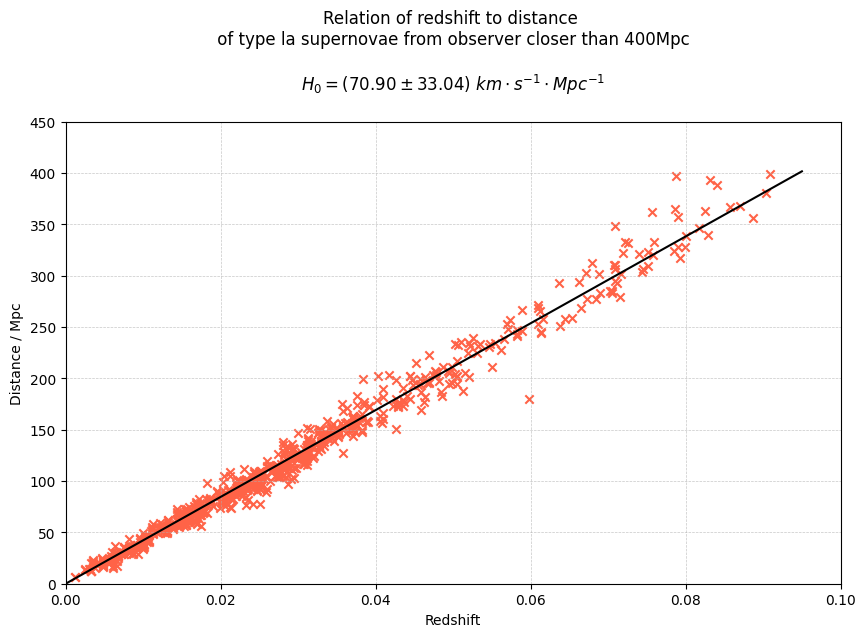

In [ ]:
x = np.linspace(0,0.095,50)

fig = plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.scatter(dfSn400["redshift"],dfSn400["sn_dist/Mpc"],color="tomato",marker="x")
ax.plot(x,distance(x,H),color="black",linestyle="solid")
ax.set_xlabel("Redshift")
ax.set_ylabel("Distance / Mpc")
ax.set_title("Relation of redshift to distance \n of type la supernovae from observer closer than 400Mpc \n \n"
             rf"$H_0 = ({H0:.2f} \pm {H0unc:.2f})~km\cdot s^{{-1}}\cdot Mpc^{{-1}} $""\n")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlim(0,0.1)
ax.set_ylim(0,450)
ax.tick_params(axis='both', which='minor', bottom=False,left=False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

$\large \text{Part C.2:~Comparison of result with official measurements}$

Recent recognised measurements of the Hubble constant are 
$
\begin{align}
H_0 &= (73.04 \pm 1.04)~ km\cdot s^{{-1}}\cdot Mpc^{{-1}} \\
&=(67.4 \pm 0.5)~ km\cdot s^{{-1}}\cdot Mpc^{{-1}} \\
\end{align}
$

My result of $H_0=(70.90 \pm 33.04)~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$ lies within the uncertainty ranges of both of these measurements, i.e. it agrees with them both.

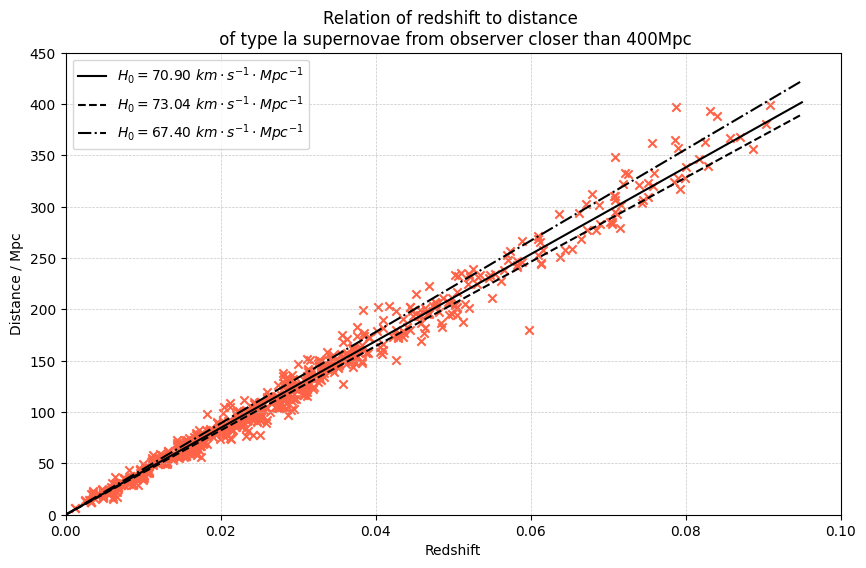

In [ ]:
x = np.linspace(0,0.095,50)

H1 = 73040
H2 = 67400

fig = plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.scatter(dfSn400["redshift"],dfSn400["sn_dist/Mpc"],color="tomato",marker="x")
ax.plot(x,distance(x,H),color="black",linestyle="solid",label=fr"$H_0 = 70.90~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$")
ax.plot(x,distance(x,H1),color="black",linestyle="--",label=fr"$H_0 = 73.04~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$")
ax.plot(x,distance(x,H2),color="black",linestyle="-.",label=fr"$H_0 = 67.40~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$")
ax.set_xlabel("Redshift")
ax.set_ylabel("Distance / Mpc")
ax.set_title("Relation of redshift to distance \n of type la supernovae from observer closer than 400Mpc")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.legend()
ax.set_xlim(0,0.1)
ax.set_ylim(0,450)

ax.tick_params(axis='both', which='minor', bottom=False,left=False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

To investigate the validity of the measurements, I will plot the lines of best fit over a greater range of values ($>400Mpc$). A logarithmic scale won't be used here even though the full range of data points is considered to retain the clarity of the implications made by the lines of best fit, since a logarithmic scale would obfuscate their meaning and possible interpretations.

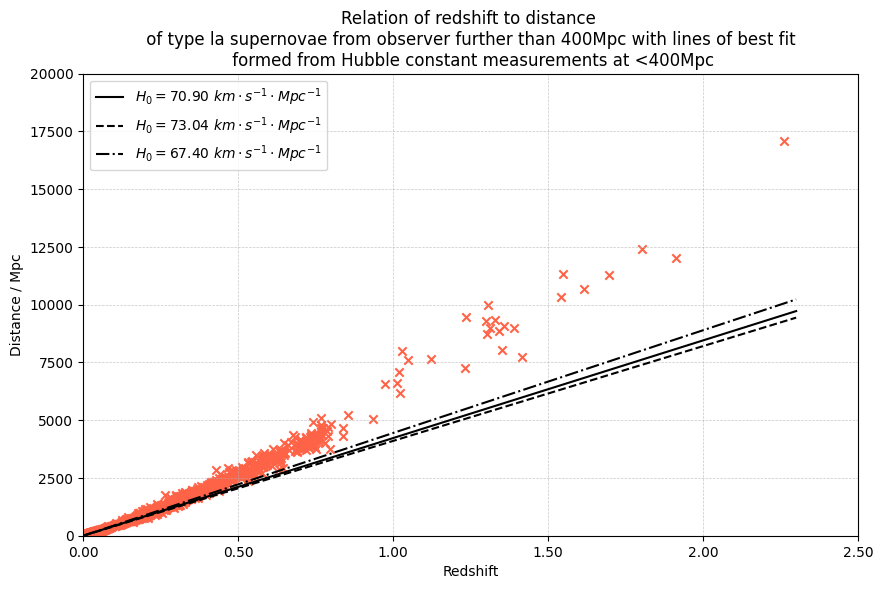

In [ ]:
x = np.linspace(0,2.3,50)

H1 = 73040
H2 = 67400

fig = plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.scatter(dfSn["redshift"],dfSn["sn_dist/Mpc"],color="tomato",marker="x")
ax.plot(x,distance(x,H),color="black",linestyle="solid",label=fr"$H_0 = 70.90~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$")
ax.plot(x,distance(x,H1),color="black",linestyle="--",label=fr"$H_0 = 73.04~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$")
ax.plot(x,distance(x,H2),color="black",linestyle="-.",label=fr"$H_0 = 67.40~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$")
ax.set_xlabel("Redshift")
ax.set_ylabel("Distance / Mpc")
ax.set_title("Relation of redshift to distance \n of type la supernovae from observer further than 400Mpc with lines of best fit \n formed from Hubble constant measurements at <400Mpc")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.legend()
ax.set_xlim(0,2.50)
ax.set_ylim(0,20000)

ax.tick_params(axis='both', which='minor', bottom=False,left=False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

From this, it is clear that these values of $H_0$ are not suitable beyond the $400~Mpc$ distance, since the lines of best fit do not fit the dataset.

To investigate this, I will choose a greater range of distances to consider and recalculate the Hubble constant. I will choose to consider distances up to $5000~Mpc$, since approximately beyond this distance, the data points become sparse and more spread out, reducing accuracy.

In [ ]:
dfSn5000 = dfSn[dfSn["sn_dist/Mpc"] <= 5000]
dfSn5000.head()

,SN_ID,redshift,redshift_unc,sn_app_mag,sn_app_mag_unc,sn_dist_mod,sn_dist_mod_unc,sn_dist/Mpc,sn_dist_unc/Mpc
0,2011fe,0.00122,0.00084,9.74571,1.516210,28.978604,1.520502,6.247708,4.374751
1,2011fe,0.00122,0.00084,9.80286,1.517230,29.035754,1.521519,6.414322,4.494422
2,2012cg,0.00256,0.00084,11.47030,0.781906,30.703194,0.790196,13.824159,5.030596
3,2012cg,0.00256,0.00084,11.49190,0.798612,30.724794,0.806731,13.962357,5.187200
4,1994DRichmond,0.00299,0.00084,11.52270,0.880798,30.755594,0.888166,14.161809,5.792399


In [ ]:
popt,pcov=curve_fit(distance, dfSn5000["redshift"],dfSn5000["sn_dist/Mpc"])
H_s2 = (popt[0]*10**(-3)).round(2)
H_s2unc = (pcov[0][0]*10**(-3)).round(2)


Markdown(
    rf"$$\Large \text{{For sample 2, }} H_0=({H_s2:.2f} \pm {H_s2unc:.2f})~km\cdot s^{{-1}}\cdot Mpc^{{-1}}"
    rf"< (\text{{measurements with <400Mpc}})$$"
)

$$\Large \text{For sample 2, } H_0=(56.95 \pm 15.48)~km\cdot s^{-1}\cdot Mpc^{-1}< (\text{measurements with <400Mpc})$$

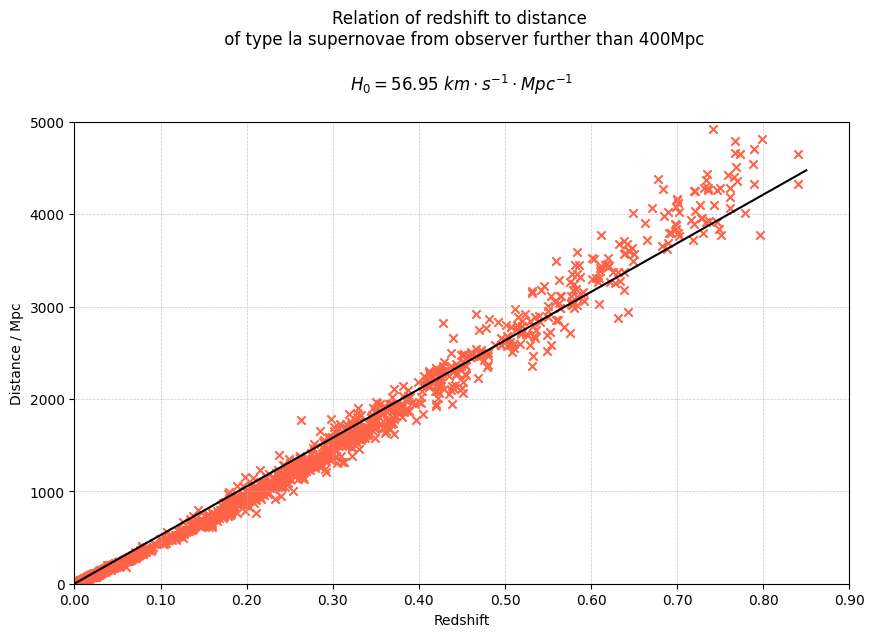

In [ ]:
x = np.linspace(0,0.85,50)

H1 = 73040
H2 = 67400

fig = plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.scatter(dfSn5000["redshift"],dfSn5000["sn_dist/Mpc"],color="tomato",marker="x")
ax.plot(x,distance(x,(H_s2)*10**3),color="black",linestyle="solid")
ax.set_xlabel("Redshift")
ax.set_ylabel("Distance / Mpc")
ax.set_title("Relation of redshift to distance \n of type la supernovae from observer further than 400Mpc\n\n" fr"$H_0 = 56.95~ km\cdot s^{{-1}}\cdot Mpc^{{-1}}$""\n")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlim(0,0.9)
ax.set_ylim(0,5000)

ax.tick_params(axis='both', which='minor', bottom=False,left=False)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()

This new sample range led to a smaller measurement and uncertainty of the Hubble constant due to a steeper gradient in the distance-redshift plot. This may hint toward some alternative conclusions.


$$\large \text{1.Linear model for distance and redshift relation isn't accurate}$$
An explanation for the gradient growing steeper with a greater sample range may be that the relation, $ D = \frac{c}{H_0}z $ isn't accurate, and the relationship in reality resembles a polynomial, $ D = \frac{c}{H_0}z^n $, where the gradient increases at some rate.


$$\large \text{2. }H_0 \text{ may not be constant}$$
It's possible that the changed Hubble constant is a correct prediction of reality, implying that it is smaller for greater distances from the observer, further implying that the expansion of the universe is slower for far-away objects. This conclusion is supported by the theory of dark matter, which supposes that the expansion of the universe is accelerating over time, meaning it was slower in the past, which is equivalent to say that it is slower for far-away objects.

$$\large \text{3.Interference or systematic error during data collection}$$
It is possible that the data collected and used is inaccurate to reality due to some systematic error causing redshift to be skewed at a rate proportional to the distance of the object observed, leading to models not fitting as expected. The only way to amend this would be to check instruments used for faults and re-record the data.